# Support Vector Machine — Mushroom Classification
**Objective:** Classify mushrooms as **Edible** or **Poisonous** using SVM with multiple kernels, hyperparameter tuning, and thorough evaluation.

**Dataset:** `mushroom.csv` — 2,000 samples · 23 categorical + 2 numerical features · Binary target

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'poisonous': 'tomato', 'edible': 'steelblue'}
print('All libraries loaded.')

All libraries loaded.


---
## Task 1 — Exploratory Data Analysis (EDA)

In [2]:
# Load dataset
df = pd.read_csv('mushroom.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)  # drop index column
print('Shape:', df.shape)
df.head()

Shape: (2000, 25)


,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [3]:
# Basic info
print('Data Types:')
print(df.dtypes)
print()
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'class']
num_cols = ['stalk_height', 'cap_diameter']
print(f'Categorical features : {len(cat_cols)}')
print(f'Numerical features   : {len(num_cols)}')
print(f'Target               : class')

Data Types:
cap_shape                       str
cap_surface                     str
cap_color                       str
bruises                         str
odor                            str
gill_attachment                 str
gill_spacing                    str
gill_size                       str
gill_color                      str
stalk_shape                     str
stalk_root                      str
stalk_surface_above_ring        str
stalk_surface_below_ring        str
stalk_color_above_ring          str
stalk_color_below_ring          str
veil_type                       str
veil_color                      str
ring_number                     str
ring_type                       str
spore_print_color               str
population                      str
habitat                         str
class                           str
stalk_height                float64
cap_diameter                float64
dtype: object

Categorical features : 22
Numerical features   : 2
Target               :

In [4]:
# Missing values
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.sum() > 0
      else '  No missing values — dataset is complete.')

Missing Values:
  No missing values — dataset is complete.


In [5]:
# Unique values per categorical feature
print('Unique Values per Categorical Feature:')
uniq_df = pd.DataFrame({
    'Feature'     : cat_cols,
    'Unique Count': [df[c].nunique() for c in cat_cols],
    'Values'      : [', '.join(df[c].unique()) for c in cat_cols]
})
uniq_df

Unique Values per Categorical Feature:


,Feature,Unique Count,Values
0,cap_shape,5,"sunken, flat, bell, convex, conical"
1,cap_surface,4,"scaly, fibrous, grooves, smooth"
2,cap_color,9,"white, red, purple, pink, yellow, brown, green..."
3,bruises,2,"no, yes"
4,odor,9,"anise, foul, fishy, musty, spicy, none, pungen..."
5,gill_attachment,4,"descending, notched, free, attached"
6,gill_spacing,3,"distant, crowded, close"
7,gill_size,2,"broad, narrow"
8,gill_color,12,"pink, chocolate, purple, orange, buff, black, ..."
9,stalk_shape,2,"tapering, enlarging"


In [6]:
# Summary statistics for numerical features
print('Numerical Feature Statistics:')
df[num_cols].describe().round(3)

Numerical Feature Statistics:


,stalk_height,cap_diameter
count,2000.000,2000.000
mean,8.449,12.314
std,3.697,7.049
min,2.000,1.000
25%,5.291,5.724
50%,8.319,12.125
75%,11.781,18.699
max,15.095,25.000


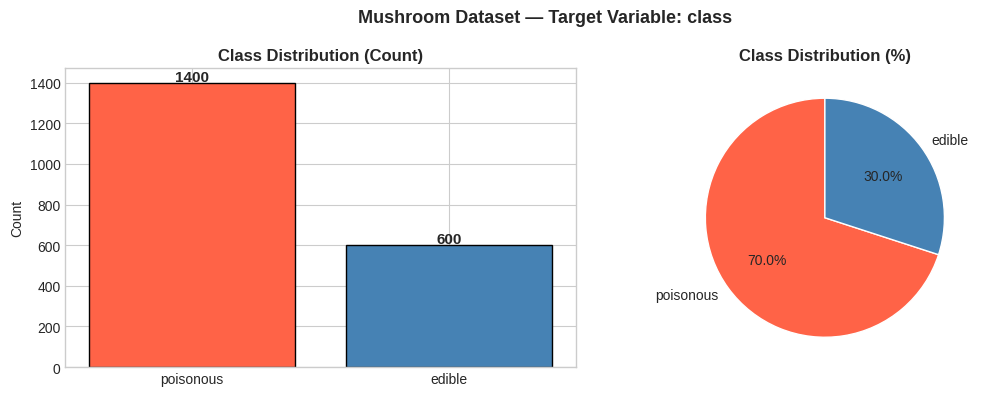

Poisonous: 1400  |  Edible: 600  |  Ratio: 2.33:1


In [7]:
# --- Target class distribution ---
class_counts = df['class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=[COLORS[c] for c in class_counts.index],
                   edgecolor='black')
for bar, v in zip(bars, class_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 str(v), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=[COLORS[c] for c in class_counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.suptitle('Mushroom Dataset — Target Variable: class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Poisonous: {class_counts["poisonous"]}  |  Edible: {class_counts["edible"]}  '
      f'|  Ratio: {class_counts["poisonous"]/class_counts["edible"]:.2f}:1')

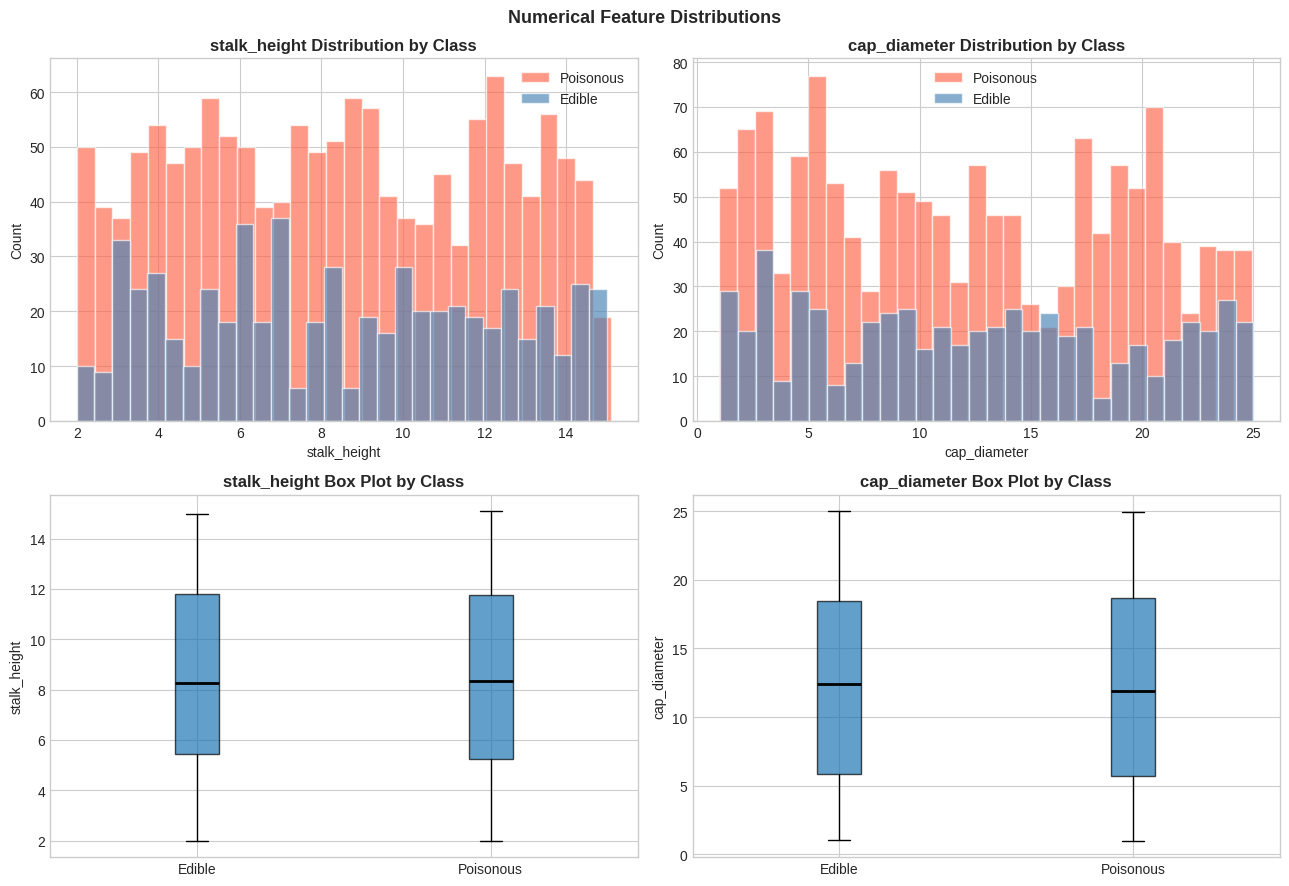

In [8]:
# --- Numerical feature distributions ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes[0], num_cols):
    for cls, color in COLORS.items():
        subset = df[df['class'] == cls][col]
        ax.hist(subset, bins=30, alpha=0.65, color=color,
                edgecolor='white', label=cls.capitalize())
    ax.set_title(f'{col} Distribution by Class', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.legend()

for ax, col in zip(axes[1], num_cols):
    ax.boxplot(
        [df[df['class']==cls][col].values for cls in ['edible','poisonous']],
        labels=['Edible','Poisonous'], patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='black', linewidth=2)
    )
    ax.set_title(f'{col} Box Plot by Class', fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Numerical Feature Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

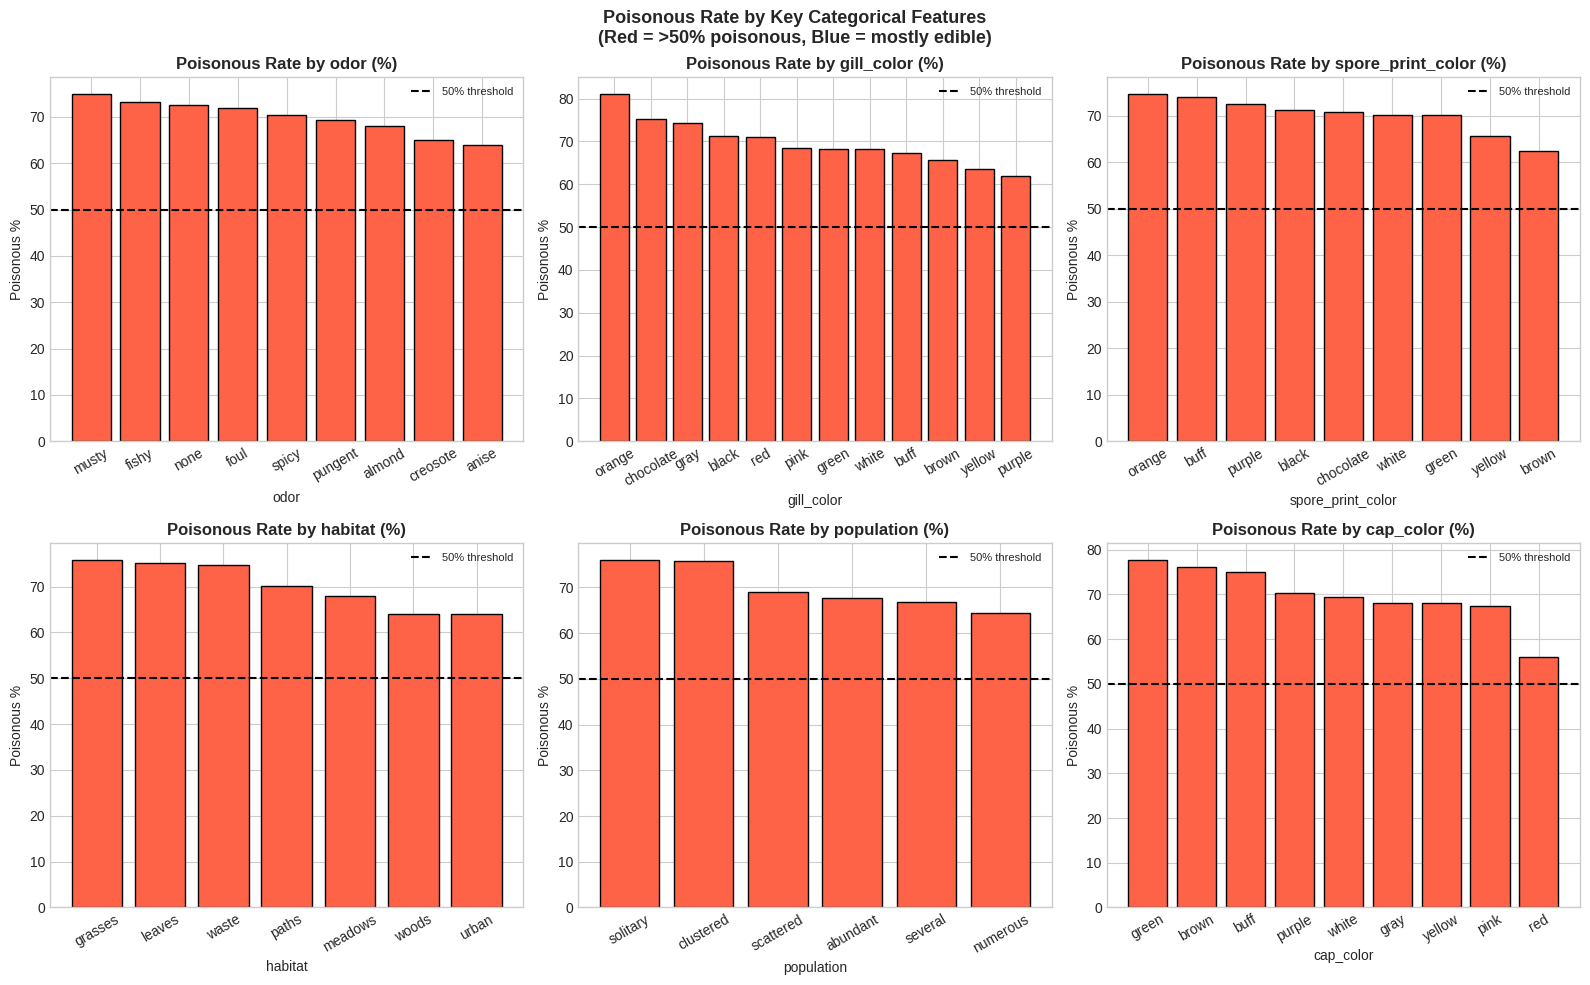

In [9]:
# --- Key categorical feature analysis ---
key_cats = ['odor', 'gill_color', 'spore_print_color',
            'habitat', 'population', 'cap_color']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    poison_rate = df.groupby(col)['class'].apply(
        lambda x: (x == 'poisonous').mean() * 100
    ).sort_values(ascending=False)

    bar_colors = ['tomato' if v > 50 else 'steelblue'
                  for v in poison_rate.values]
    bars = axes[i].bar(poison_rate.index, poison_rate.values,
                       color=bar_colors, edgecolor='black')
    axes[i].axhline(50, color='black', linestyle='--',
                    linewidth=1.5, label='50% threshold')
    axes[i].set_title(f'Poisonous Rate by {col} (%)',
                      fontweight='bold')
    axes[i].set_ylabel('Poisonous %')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

plt.suptitle('Poisonous Rate by Key Categorical Features\n'
             '(Red = >50% poisonous, Blue = mostly edible)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

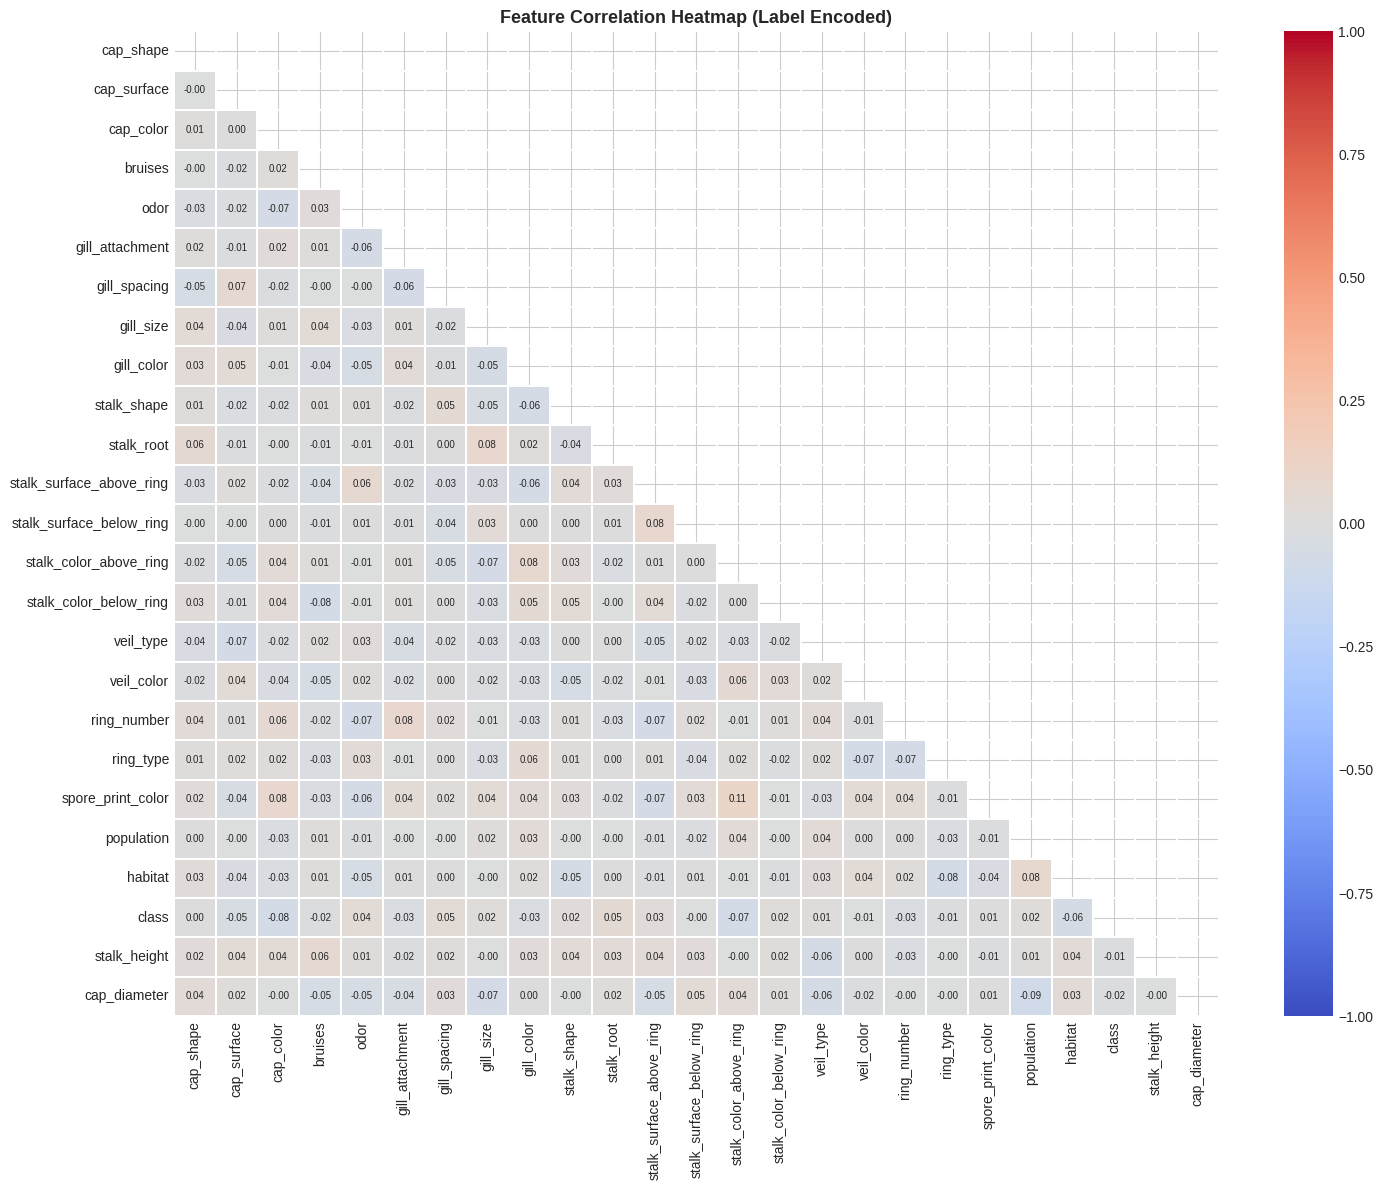

In [10]:
# --- Correlation heatmap (after encoding) ---
df_enc_corr = df.copy()
for col in df_enc_corr.select_dtypes(include='object').columns:
    df_enc_corr[col] = LabelEncoder().fit_transform(df_enc_corr[col])

corr = df_enc_corr.corr()
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.3,
            vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap (Label Encoded)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Top correlations with class
class_corr = corr['class'].drop('class').abs().sort_values(ascending=False)
print('Top 10 Features Correlated with Class (|r|):')
print(class_corr.head(10).round(4).to_string())

Top 10 Features Correlated with Class (|r|):
cap_color                   0.0780
stalk_color_above_ring      0.0716
habitat                     0.0620
stalk_root                  0.0542
gill_spacing                0.0465
cap_surface                 0.0464
odor                        0.0395
stalk_surface_above_ring    0.0310
ring_number                 0.0292
gill_attachment             0.0282


---
## Task 2 — Data Preprocessing

In [12]:
# Encode all categorical features with LabelEncoder
df_model = df.copy()
le_dict  = {}

for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col]  = le

print('Label encoding complete for all categorical columns.')
print(f'Target mapping — class: {dict(zip(le_dict["class"].classes_, le_dict["class"].transform(le_dict["class"].classes_)))}')
df_model.head()

Label encoding complete for all categorical columns.
Target mapping — class: {'edible': np.int64(0), 'poisonous': np.int64(1)}


,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,4,2,7,0,1,1,2,0,7,1,...,0,0,2,6,3,1,5,1,14.276173,5.054983
1,4,0,6,0,1,3,1,1,3,0,...,1,0,2,6,1,2,5,0,3.952715,19.068319
2,3,1,5,1,4,1,1,0,8,1,...,1,3,2,6,6,0,5,1,9.054265,7.205884
3,0,2,4,1,3,3,0,0,6,0,...,0,3,2,0,4,1,0,1,5.226499,20.932692
4,3,3,8,1,5,2,1,1,6,0,...,1,2,0,4,8,1,4,1,14.037532,12.545245


In [13]:
# Features and target
all_features = [c for c in df_model.columns if c != 'class']
X = df_model[all_features]
y = df_model['class']

print(f'Features : {X.shape[1]}  {all_features}')
print(f'Target   : {y.shape[0]} samples  |  0=edible, 1=poisonous')

Features : 24  ['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape', 'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring', 'stalk_color_above_ring', 'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat', 'stalk_height', 'cap_diameter']
Target   : 2000 samples  |  0=edible, 1=poisonous


In [14]:
# Train / Test split — 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,} samples  (80%)')
print(f'Test  : {len(X_test):,}   samples  (20%)')
print(f'Train class dist: {dict(y_train.value_counts())}')
print(f'Test  class dist: {dict(y_test.value_counts())}')

Train : 1,600 samples  (80%)
Test  : 400   samples  (20%)
Train class dist: {1: np.int64(1120), 0: np.int64(480)}
Test  class dist: {1: np.int64(280), 0: np.int64(120)}


In [15]:
# StandardScaler — essential for SVM (distance-based)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('StandardScaler applied — SVM is sensitive to feature scale.')
print(f'Train scaled: mean≈{X_train_sc.mean():.4f}  std≈{X_train_sc.std():.4f}')

StandardScaler applied — SVM is sensitive to feature scale.
Train scaled: mean≈0.0000  std≈1.0000


---
## Task 3 — Data Visualization

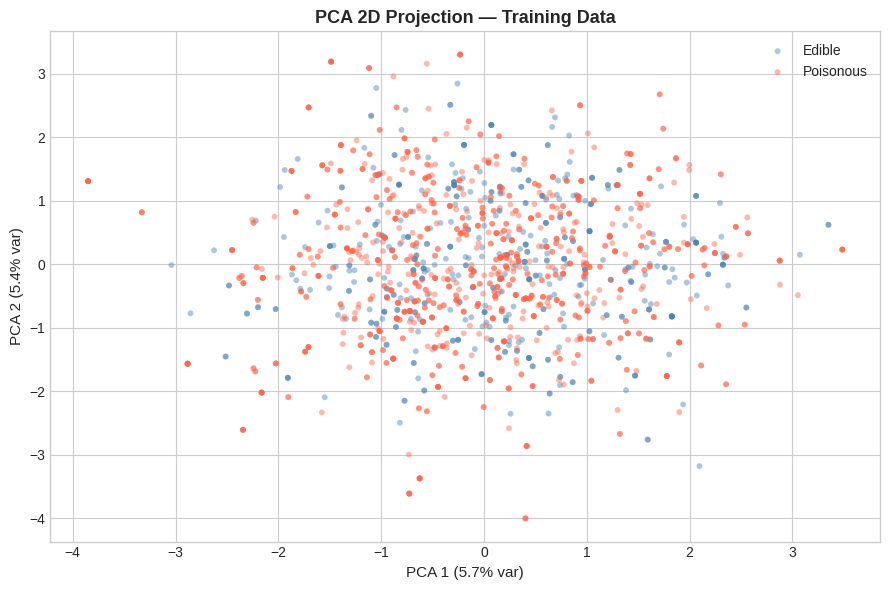

Total variance explained: 11.1%


In [16]:
# PCA 2D projection for scatter plot
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_train_sc)

label_names = {0: 'Edible', 1: 'Poisonous'}
pca_colors  = {0: 'steelblue', 1: 'tomato'}

plt.figure(figsize=(9, 6))
for cls_val, name in label_names.items():
    mask = y_train.values == cls_val
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=pca_colors[cls_val], alpha=0.45, s=18,
                label=name, edgecolors='none')
plt.xlabel(f'PCA 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)',
           fontsize=11)
plt.ylabel(f'PCA 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)',
           fontsize=11)
plt.title('PCA 2D Projection — Training Data',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(f'Total variance explained: {pca2.explained_variance_ratio_.sum()*100:.1f}%')

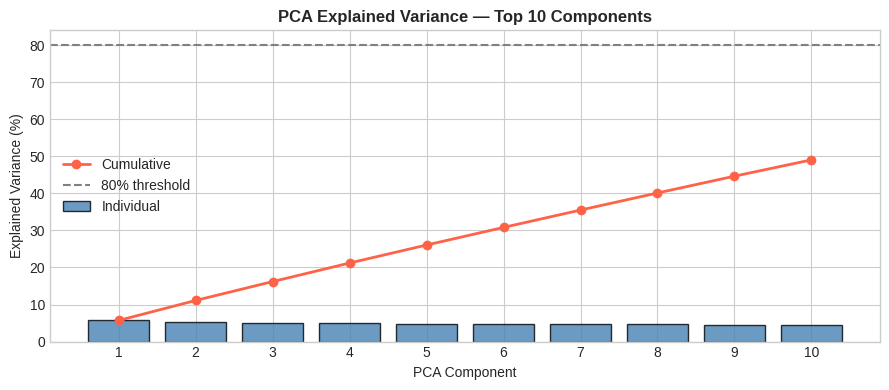

In [17]:
# PCA 3-component variance
pca_var = PCA(n_components=10, random_state=42)
pca_var.fit(X_train_sc)
cum_var = np.cumsum(pca_var.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.bar(range(1, 11), pca_var.explained_variance_ratio_*100,
        color='steelblue', edgecolor='black', alpha=0.8,
        label='Individual')
plt.plot(range(1, 11), cum_var, 'o-', color='tomato',
         linewidth=2, label='Cumulative')
plt.axhline(80, color='gray', linestyle='--',
            linewidth=1.5, label='80% threshold')
plt.xlabel('PCA Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Explained Variance — Top 10 Components',
          fontweight='bold')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

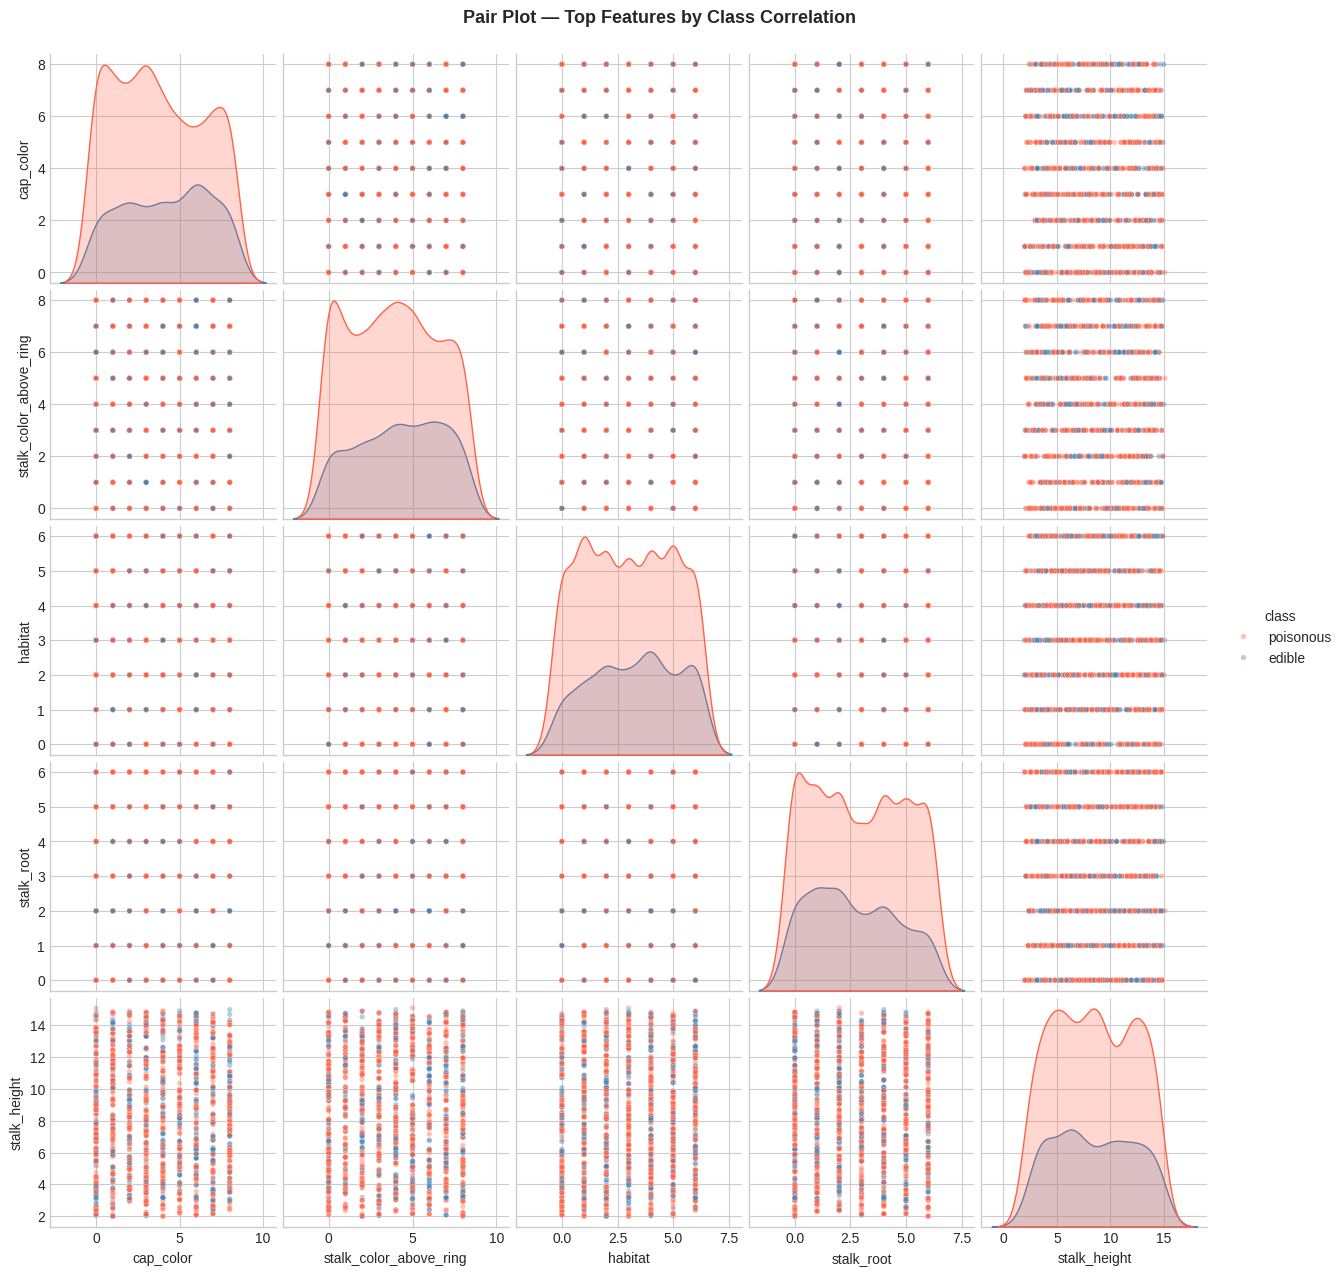

In [18]:
# Pair plot — top 4 features + numerical features
top_feats = class_corr.head(4).index.tolist() + num_cols
top_feats = list(dict.fromkeys(top_feats))[:5]   # unique, max 5

df_pair = df_model[top_feats].copy()
df_pair['class'] = df['class']

g = sns.pairplot(df_pair, hue='class',
                 palette={'poisonous':'tomato','edible':'steelblue'},
                 plot_kws={'alpha':0.4, 's':15},
                 diag_kind='kde')
g.fig.suptitle('Pair Plot — Top Features by Class Correlation',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

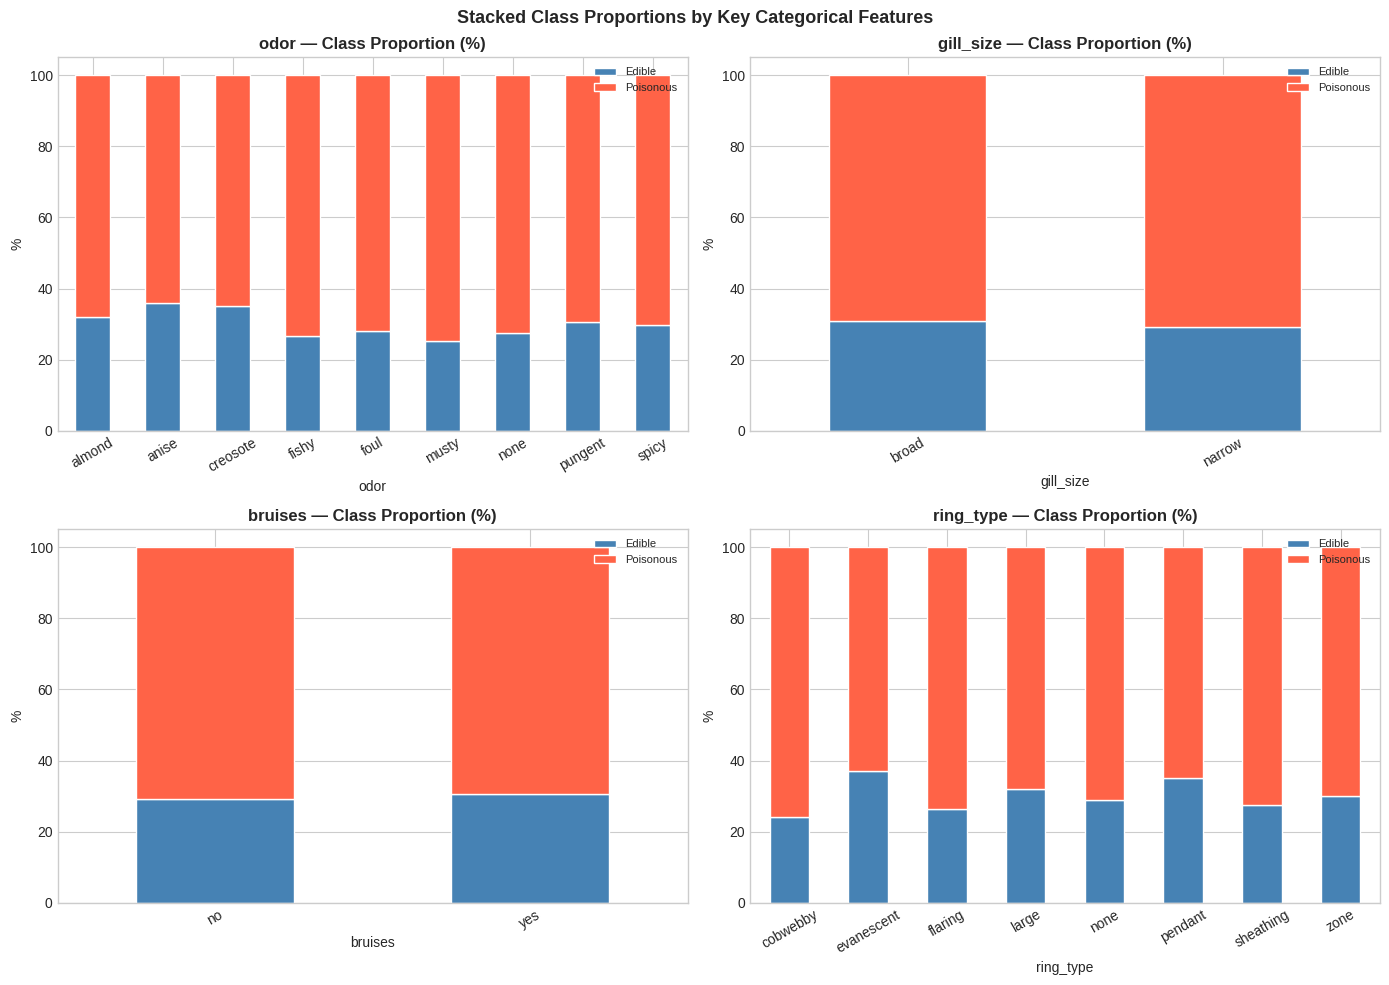

In [19]:
# Categorical feature stacked bar — edible vs poisonous proportions
highlight_cats = ['odor', 'gill_size', 'bruises', 'ring_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(highlight_cats):
    ct = pd.crosstab(df[col], df['class'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['steelblue','tomato'], edgecolor='white')
    axes[i].set_title(f'{col} — Class Proportion (%)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Edible','Poisonous'], loc='upper right', fontsize=8)

plt.suptitle('Stacked Class Proportions by Key Categorical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

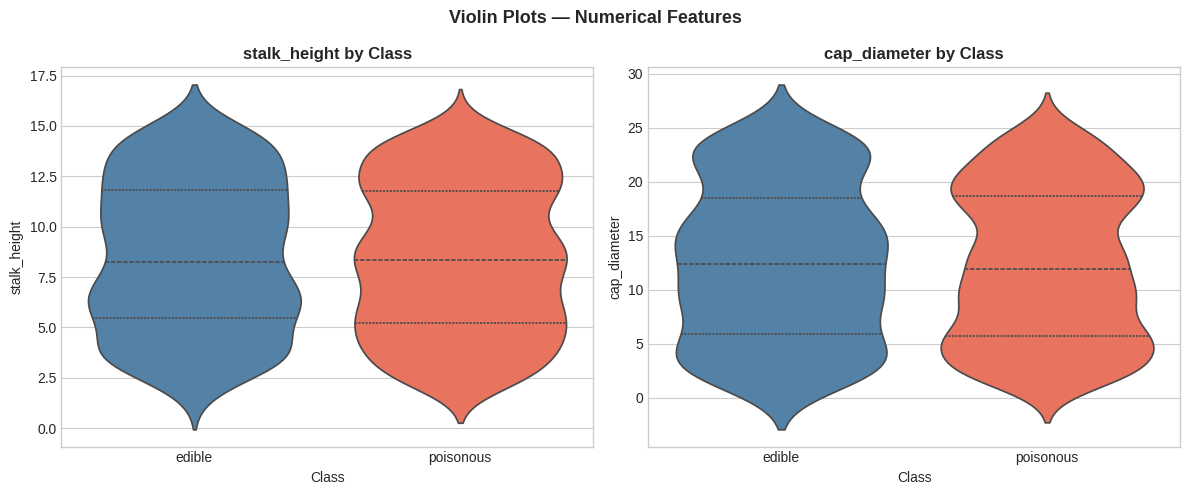

In [20]:
# Violin plots — numerical features by class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, x='class', y=col, ax=ax,
                   palette=COLORS, order=['edible','poisonous'],
                   inner='quartile')
    ax.set_title(f'{col} by Class', fontweight='bold')
    ax.set_xlabel('Class')
plt.suptitle('Violin Plots — Numerical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 4 — SVM Implementation

In [21]:
# Evaluation helper
def eval_svm(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    # ROC-AUC (decision_function if available)
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X_te)
    else:
        scores = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, scores)

    cv = cross_val_score(model, X_tr, y_tr, cv=5,
                         scoring='accuracy').mean()

    print(f'--- {name} ---')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  CV Acc    : {cv:.4f}  (5-fold)')
    print()
    return {'Model':name, 'Accuracy':acc, 'Precision':prec,
            'Recall':rec, 'F1':f1, 'ROC_AUC':auc,
            'CV_Acc':cv, 'y_pred':y_pred, 'scores':scores}

print('Evaluation helper defined.')

Evaluation helper defined.


In [22]:
# Baseline SVM — RBF kernel, default params
svm_base = SVC(kernel='rbf', C=1.0, gamma='scale',
               random_state=42, probability=True)
res_base = eval_svm('Baseline SVM (RBF, C=1)',
                     svm_base, X_train_sc, X_test_sc, y_train, y_test)

--- Baseline SVM (RBF, C=1) ---
  Accuracy  : 0.7750
  Precision : 0.7669
  Recall    : 0.9750
  F1-Score  : 0.8585
  ROC-AUC   : 0.8459
  CV Acc    : 0.7844  (5-fold)



In [23]:
# Full classification report
print('Classification Report — Baseline SVM:')
print(classification_report(y_test, res_base['y_pred'],
                             target_names=['Edible','Poisonous']))

Classification Report — Baseline SVM:
              precision    recall  f1-score   support

      Edible       0.84      0.31      0.45       120
   Poisonous       0.77      0.97      0.86       280

    accuracy                           0.78       400
   macro avg       0.80      0.64      0.65       400
weighted avg       0.79      0.78      0.74       400



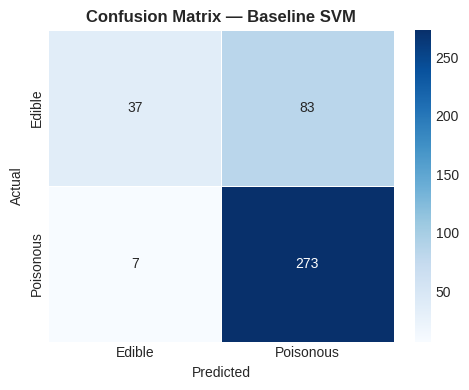

In [24]:
# Confusion Matrix
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Edible','Poisonous'],
                yticklabels=['Edible','Poisonous'],
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm(y_test, res_base['y_pred'], 'Confusion Matrix — Baseline SVM', ax)
plt.tight_layout(); plt.show()

---
## Task 5 — Visualization of SVM Results

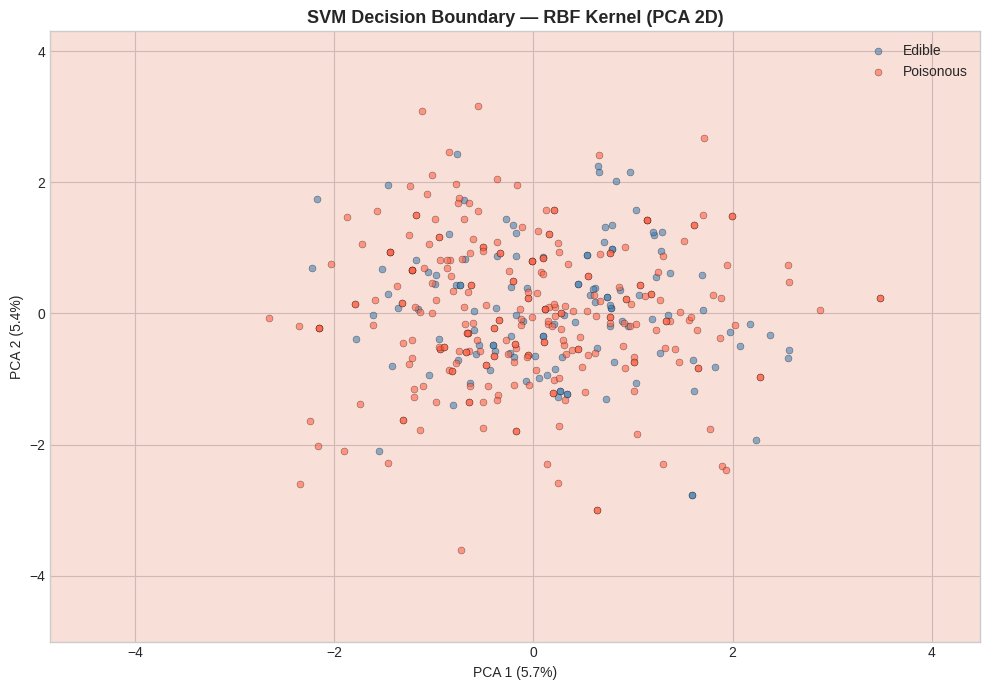

In [25]:
# Decision boundary in PCA 2D space
pca_bound = PCA(n_components=2, random_state=42)
X_tr_2d   = pca_bound.fit_transform(X_train_sc)
X_te_2d   = pca_bound.transform(X_test_sc)

# Train SVM on 2D PCA features for boundary
svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_2d.fit(X_tr_2d, y_train)

# Mesh grid
x_min, x_max = X_tr_2d[:,0].min()-1, X_tr_2d[:,0].max()+1
y_min, y_max = X_tr_2d[:,1].min()-1, X_tr_2d[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.25,
             cmap=plt.cm.RdBu_r, levels=[-0.5, 0.5, 1.5])
plt.contour(xx, yy, Z, colors='gray',
            linewidths=0.5, levels=[0.5])

for cls_val, name, color in zip([0,1],['Edible','Poisonous'],
                                  ['steelblue','tomato']):
    mask = y_test.values == cls_val
    plt.scatter(X_te_2d[mask,0], X_te_2d[mask,1],
                c=color, alpha=0.6, s=25,
                edgecolors='black', linewidths=0.3,
                label=name)

plt.xlabel(f'PCA 1 ({pca_bound.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PCA 2 ({pca_bound.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('SVM Decision Boundary — RBF Kernel (PCA 2D)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

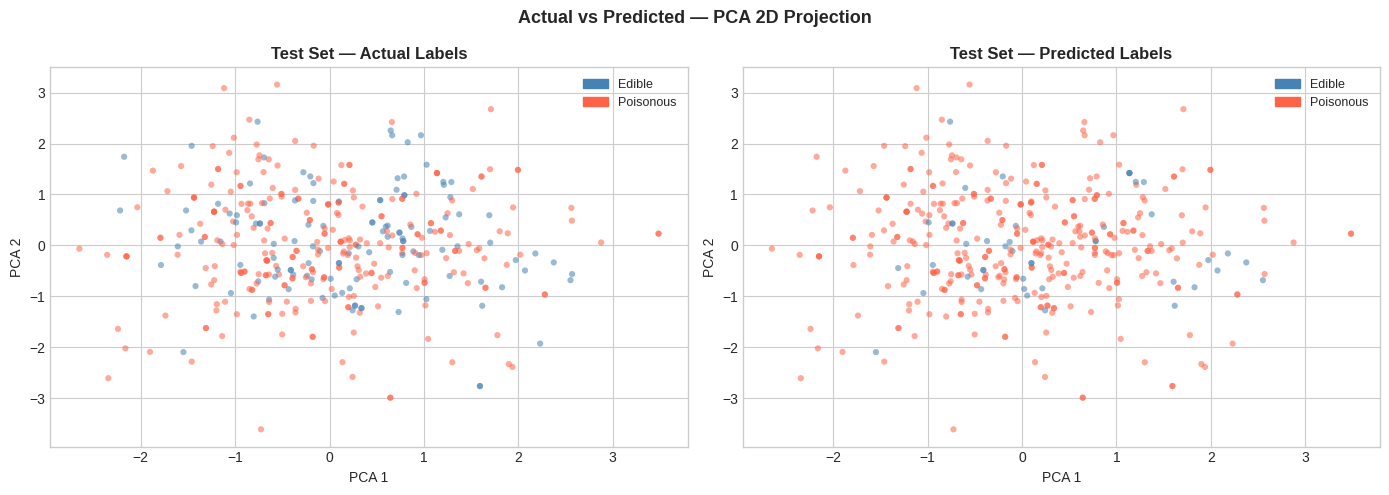

In [26]:
# Actual vs Predicted scatter in PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(
    axes,
    [y_test.values, res_base['y_pred']],
    ['Actual Labels', 'Predicted Labels']
):
    colors_pts = ['steelblue' if v == 0 else 'tomato' for v in labels]
    ax.scatter(X_te_2d[:,0], X_te_2d[:,1], c=colors_pts,
               alpha=0.55, s=20, edgecolors='none')
    ax.set_title(f'Test Set — {title}', fontweight='bold')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    patches = [mpatches.Patch(color='steelblue', label='Edible'),
               mpatches.Patch(color='tomato',    label='Poisonous')]
    ax.legend(handles=patches, fontsize=9)

plt.suptitle('Actual vs Predicted — PCA 2D Projection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

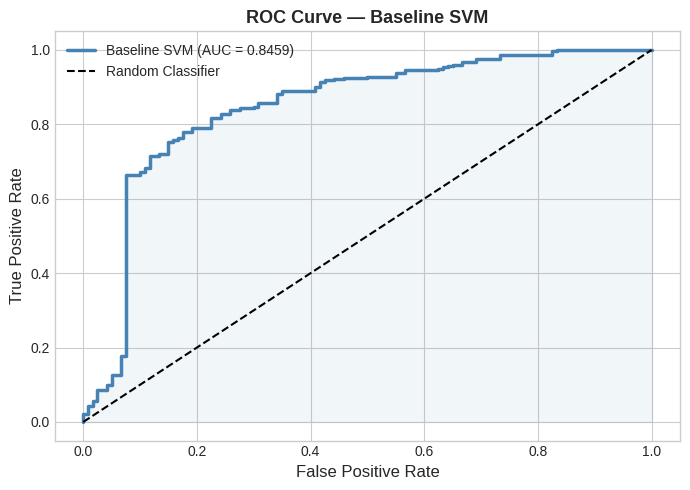

In [27]:
# ROC Curve — Baseline SVM
fpr, tpr, _ = roc_curve(y_test, res_base['scores'])
auc_val     = roc_auc_score(y_test, res_base['scores'])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2.5,
         label=f'Baseline SVM (AUC = {auc_val:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.07, color='steelblue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Baseline SVM', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Task 6 — Parameter Tuning and Optimization

In [28]:
# GridSearchCV over C and gamma for RBF kernel
param_grid_rbf = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

grid_rbf = GridSearchCV(
    SVC(kernel='rbf', random_state=42, probability=True),
    param_grid_rbf,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
grid_rbf.fit(X_train_sc, y_train)

print(f'\nBest RBF params : {grid_rbf.best_params_}')
print(f'Best CV Accuracy: {grid_rbf.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits



Best RBF params : {'C': 10, 'gamma': 'scale'}
Best CV Accuracy: 0.8331


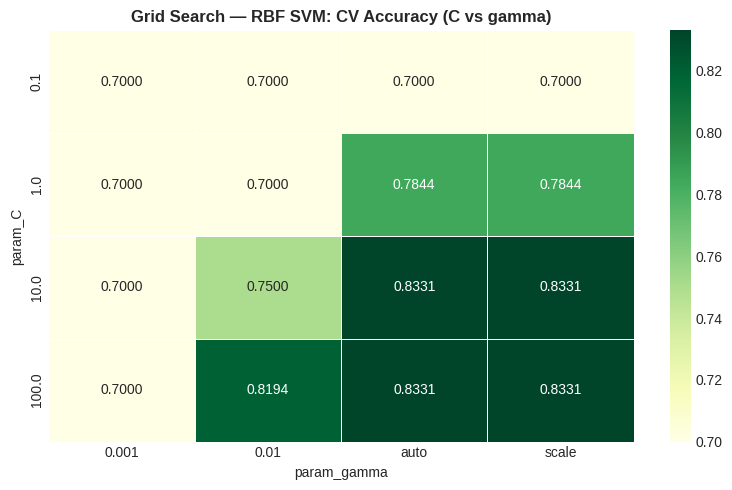

In [29]:
# GridSearch heatmap — C vs gamma
results_rbf = pd.DataFrame(grid_rbf.cv_results_)
pivot = results_rbf.pivot_table(
    index='param_C', columns='param_gamma',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5)
plt.title('Grid Search — RBF SVM: CV Accuracy (C vs gamma)',
          fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Tuned SVM — Best RBF
svm_tuned = grid_rbf.best_estimator_
res_tuned = eval_svm('Tuned SVM (RBF, GridSearchCV)',
                      svm_tuned, X_train_sc, X_test_sc, y_train, y_test)

--- Tuned SVM (RBF, GridSearchCV) ---
  Accuracy  : 0.8500
  Precision : 0.8716
  Recall    : 0.9214
  F1-Score  : 0.8958
  ROC-AUC   : 0.9067
  CV Acc    : 0.8331  (5-fold)



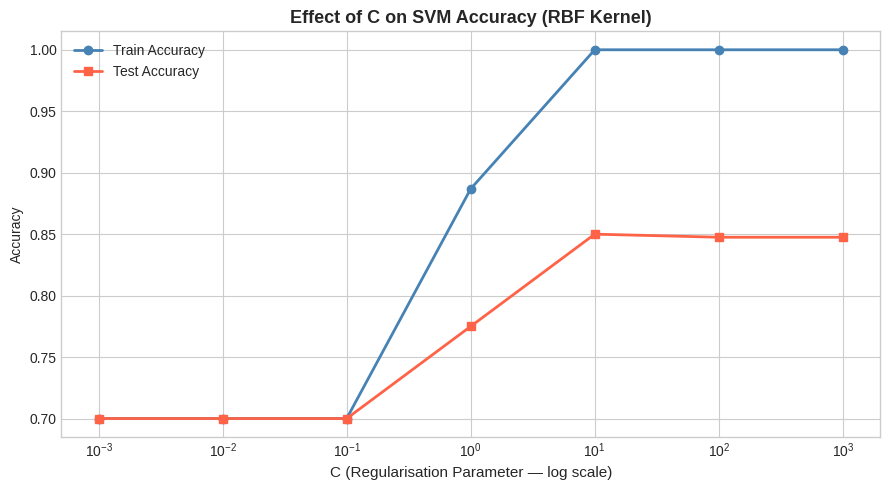

In [31]:
# C parameter effect on accuracy
C_vals   = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
tr_accs, te_accs = [], []
for c in C_vals:
    m = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    m.fit(X_train_sc, y_train)
    tr_accs.append(m.score(X_train_sc, y_train))
    te_accs.append(m.score(X_test_sc,  y_test))

plt.figure(figsize=(9, 5))
plt.semilogx(C_vals, tr_accs, 'o-', color='steelblue',
             lw=2, label='Train Accuracy')
plt.semilogx(C_vals, te_accs, 's-', color='tomato',
             lw=2, label='Test Accuracy')
plt.xlabel('C (Regularisation Parameter — log scale)', fontsize=11)
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Accuracy (RBF Kernel)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## Task 7 — Kernel Comparison and Analysis

In [32]:
# Compare all kernels
kernels = {
    'Linear'     : SVC(kernel='linear', C=1.0,
                        random_state=42, probability=True),
    'RBF'        : SVC(kernel='rbf', C=1.0, gamma='scale',
                        random_state=42, probability=True),
    'Polynomial' : SVC(kernel='poly', C=1.0, degree=3,
                        gamma='scale', random_state=42, probability=True),
    'Sigmoid'    : SVC(kernel='sigmoid', C=1.0,
                        random_state=42, probability=True),
    'Tuned RBF'  : grid_rbf.best_estimator_
}

all_results = []
roc_data    = {}

for name, model in kernels.items():
    r = eval_svm(name, model, X_train_sc, X_test_sc, y_train, y_test)
    all_results.append({k:v for k,v in r.items()
                        if k not in ['y_pred','scores']})
    fpr_k, tpr_k, _ = roc_curve(y_test, r['scores'])
    roc_data[name]  = (fpr_k, tpr_k, r['ROC_AUC'])

--- Linear ---
  Accuracy  : 0.7000
  Precision : 0.7000
  Recall    : 1.0000
  F1-Score  : 0.8235
  ROC-AUC   : 0.4754
  CV Acc    : 0.7000  (5-fold)



--- RBF ---
  Accuracy  : 0.7750
  Precision : 0.7669
  Recall    : 0.9750
  F1-Score  : 0.8585
  ROC-AUC   : 0.8459
  CV Acc    : 0.7844  (5-fold)



--- Polynomial ---
  Accuracy  : 0.8125
  Precision : 0.7954
  Recall    : 0.9857
  F1-Score  : 0.8804
  ROC-AUC   : 0.8745
  CV Acc    : 0.8156  (5-fold)



--- Sigmoid ---
  Accuracy  : 0.6725
  Precision : 0.6915
  Recall    : 0.9607
  F1-Score  : 0.8042
  ROC-AUC   : 0.3518
  CV Acc    : 0.6794  (5-fold)



--- Tuned RBF ---
  Accuracy  : 0.8500
  Precision : 0.8716
  Recall    : 0.9214
  F1-Score  : 0.8958
  ROC-AUC   : 0.9067
  CV Acc    : 0.8331  (5-fold)



In [33]:
# Comparison table
comp_df = pd.DataFrame(all_results).round(4)
print('Kernel Comparison Table:')
comp_df

Kernel Comparison Table:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_Acc
0,Linear,0.7000,0.7000,1.0000,0.8235,0.4754,0.7000
1,RBF,0.7750,0.7669,0.9750,0.8585,0.8459,0.7844
2,Polynomial,0.8125,0.7954,0.9857,0.8804,0.8745,0.8156
3,Sigmoid,0.6725,0.6915,0.9607,0.8042,0.3518,0.6794
4,Tuned RBF,0.8500,0.8716,0.9214,0.8958,0.9067,0.8331


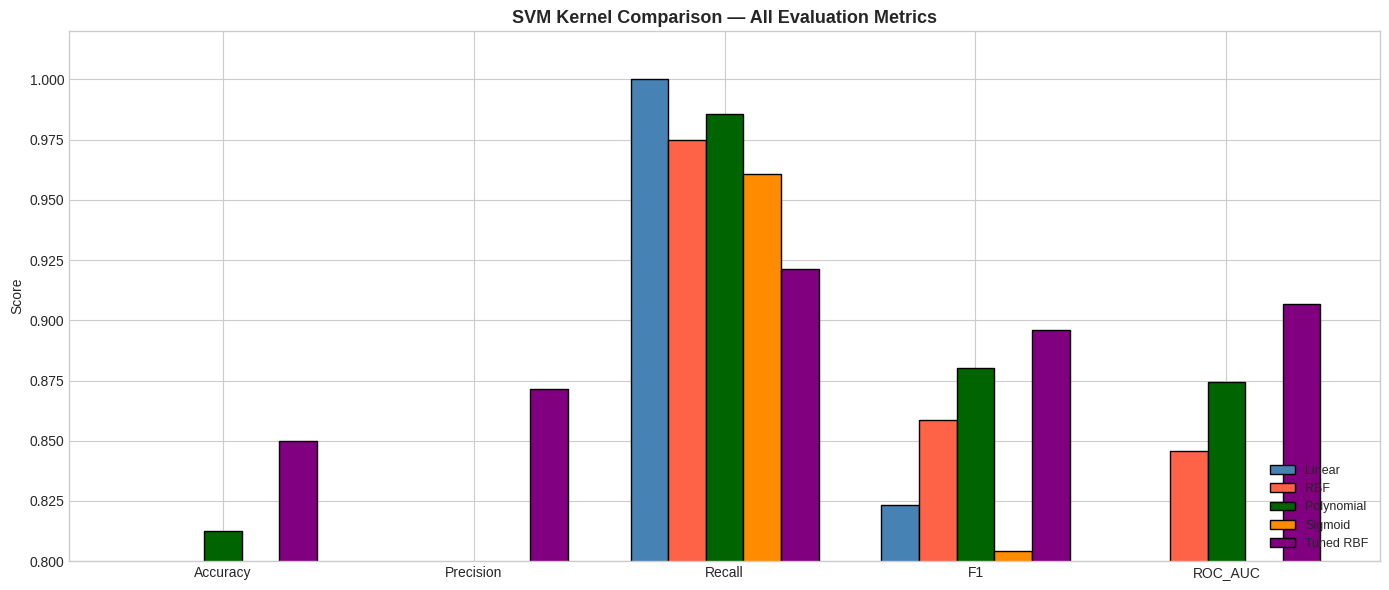

In [34]:
# Grouped bar chart — all metrics, all kernels
metrics  = ['Accuracy','Precision','Recall','F1','ROC_AUC']
n_models = len(comp_df)
x        = np.arange(len(metrics))
width    = 0.15
kcolors  = ['steelblue','tomato','darkgreen','darkorange','purple']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=row['Model'], color=kcolors[i], edgecolor='black')

ax.set_xticks(x + width*(n_models-1)/2)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Score')
ax.set_title('SVM Kernel Comparison — All Evaluation Metrics',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

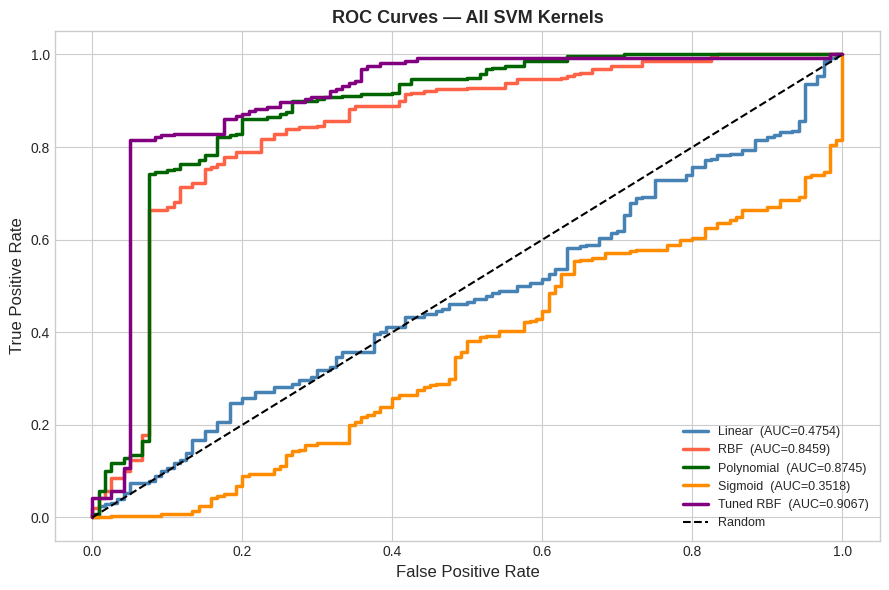

In [35]:
# ROC curves — all kernels
plt.figure(figsize=(9, 6))
for (name, (fpr_k, tpr_k, auc_k)), color in zip(
    roc_data.items(), kcolors
):
    plt.plot(fpr_k, tpr_k, lw=2.5,
             label=f'{name}  (AUC={auc_k:.4f})', color=color)

plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All SVM Kernels',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

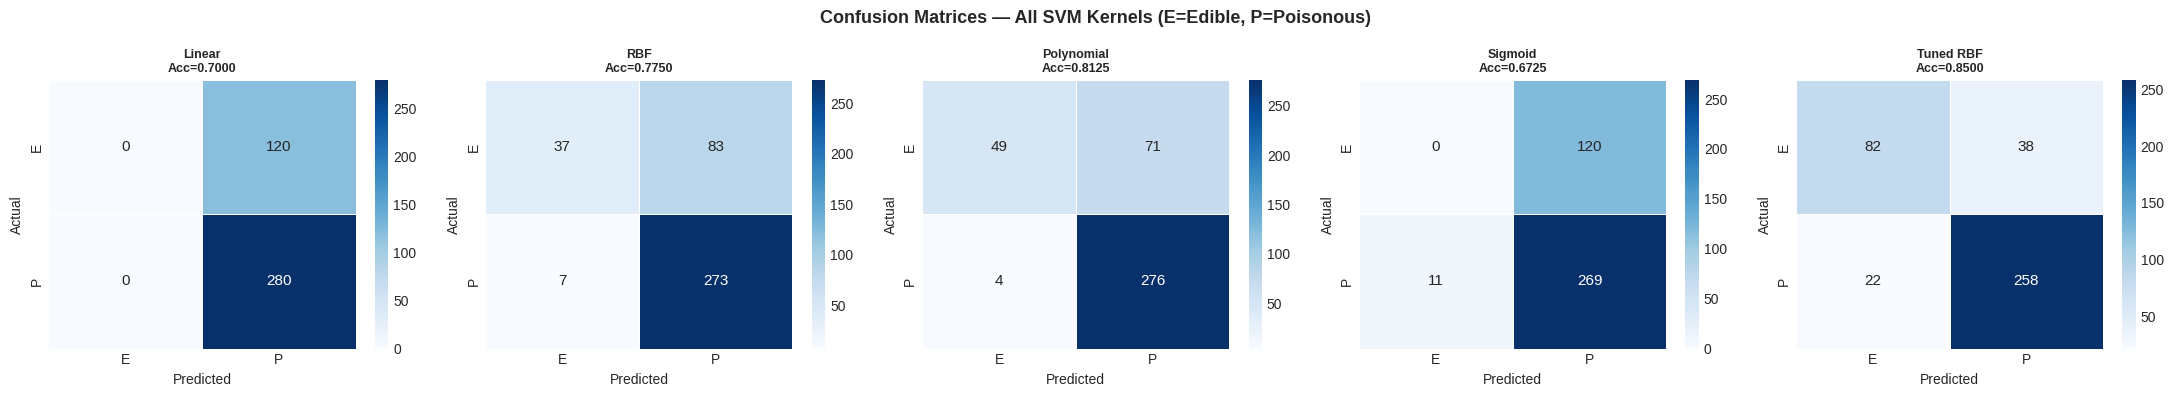

In [36]:
# Confusion matrices — all 5 models
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, kernels.items()):
    model.fit(X_train_sc, y_train)
    y_p = model.predict(X_test_sc)
    cm  = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['E','P'], yticklabels=['E','P'],
                linewidths=0.5, annot_kws={'size':11})
    acc = accuracy_score(y_test, y_p)
    ax.set_title(f'{name}\nAcc={acc:.4f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All SVM Kernels (E=Edible, P=Poisonous)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

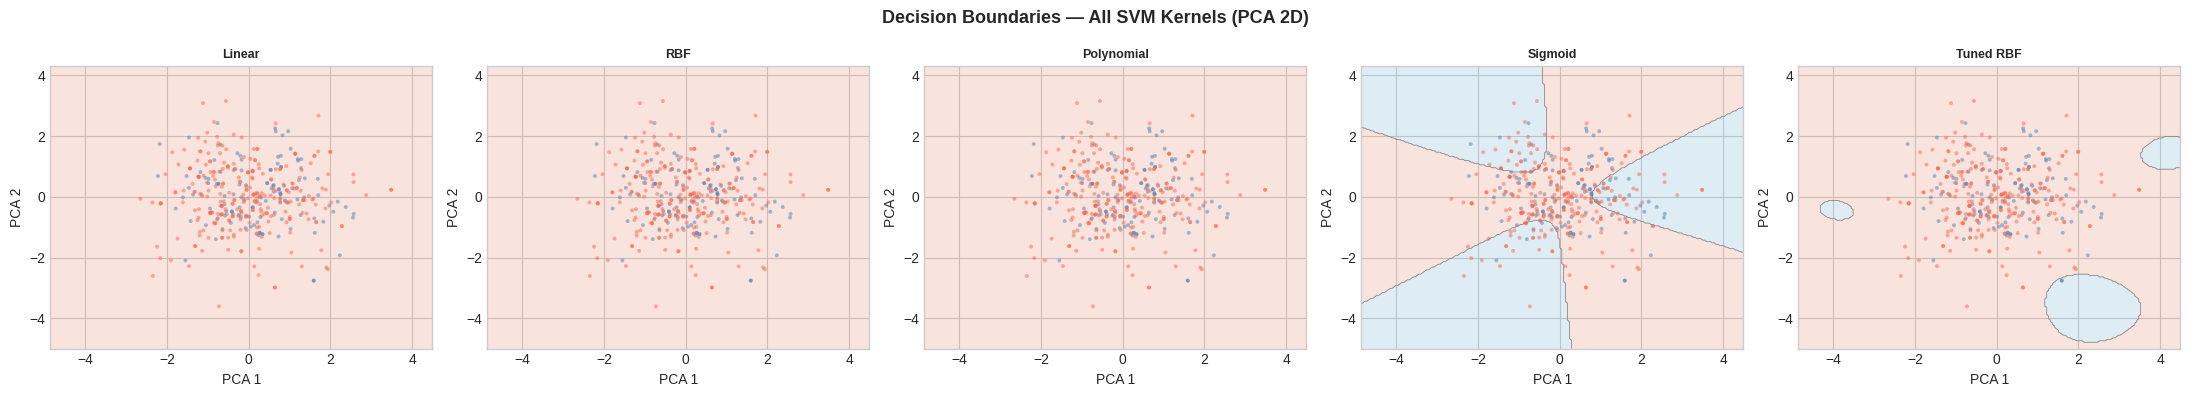

In [37]:
# Decision boundaries for all kernels in PCA 2D
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
kernel_names = ['linear','rbf','poly','sigmoid','rbf']  # last = tuned rbf
svm_2d_models = [
    SVC(kernel='linear', C=1.0, random_state=42),
    SVC(kernel='rbf',    C=1.0, gamma='scale', random_state=42),
    SVC(kernel='poly',   C=1.0, degree=3,      random_state=42),
    SVC(kernel='sigmoid',C=1.0,                random_state=42),
    SVC(kernel='rbf', C=grid_rbf.best_params_['C'],
        gamma=grid_rbf.best_params_['gamma'],   random_state=42)
]
display_names = list(kernels.keys())

xx2, yy2 = np.meshgrid(np.linspace(X_tr_2d[:,0].min()-1,
                                    X_tr_2d[:,0].max()+1, 200),
                        np.linspace(X_tr_2d[:,1].min()-1,
                                    X_tr_2d[:,1].max()+1, 200))

for ax, m_2d, dname in zip(axes, svm_2d_models, display_names):
    m_2d.fit(X_tr_2d, y_train)
    Z2 = m_2d.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
    ax.contourf(xx2, yy2, Z2, alpha=0.22,
                cmap=plt.cm.RdBu_r, levels=[-0.5,0.5,1.5])
    ax.contour(xx2, yy2, Z2, colors='gray',
               linewidths=0.5, levels=[0.5])
    for cls_v, color in [(0,'steelblue'),(1,'tomato')]:
        mask = y_test.values == cls_v
        ax.scatter(X_te_2d[mask,0], X_te_2d[mask,1],
                   c=color, alpha=0.5, s=8, edgecolors='none')
    ax.set_title(dname, fontweight='bold', fontsize=9)
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')

plt.suptitle('Decision Boundaries — All SVM Kernels (PCA 2D)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Final summary
best_row = comp_df.loc[comp_df['Accuracy'].idxmax()]
print('=' * 62)
print('FINAL SUMMARY — MUSHROOM SVM CLASSIFICATION')
print('=' * 62)
print(f'  Dataset       : mushroom.csv')
print(f'  Samples       : 2,000  |  Features: {len(all_features)}')
print(f'  Classes       : Edible (600) vs Poisonous (1,400)')
print(f'  Train / Test  : 1,600 / 400  (80/20 stratified)')
print()
print('  Kernel Results:')
for _, row in comp_df.iterrows():
    print(f"    {row['Model']:<18} Acc={row['Accuracy']:.4f}  "
          f"F1={row['F1']:.4f}  AUC={row['ROC_AUC']:.4f}")
print()
print(f"  Best Model    : {best_row['Model']}")
print(f"  Best Accuracy : {best_row['Accuracy']:.4f}")
print(f"  Best F1-Score : {best_row['F1']:.4f}")
print('=' * 62)

FINAL SUMMARY — MUSHROOM SVM CLASSIFICATION
  Dataset       : mushroom.csv
  Samples       : 2,000  |  Features: 24
  Classes       : Edible (600) vs Poisonous (1,400)
  Train / Test  : 1,600 / 400  (80/20 stratified)

  Kernel Results:
    Linear             Acc=0.7000  F1=0.8235  AUC=0.4754
    RBF                Acc=0.7750  F1=0.8585  AUC=0.8459
    Polynomial         Acc=0.8125  F1=0.8804  AUC=0.8745
    Sigmoid            Acc=0.6725  F1=0.8042  AUC=0.3518
    Tuned RBF          Acc=0.8500  F1=0.8958  AUC=0.9067

  Best Model    : Tuned RBF
  Best Accuracy : 0.8500
  Best F1-Score : 0.8958


---
## Task 7b — Analysis: SVM Strengths, Weaknesses & Practical Implications

### Kernel Performance Comparison

| Kernel | Strength | Weakness | Suitability for Mushroom Data |
|---|---|---|---|
| **Linear** | Fast, interpretable, good for linearly separable data | Fails on non-linear boundaries | Moderate — some features linearly separate classes |
| **RBF (Gaussian)** | Flexible, handles non-linear boundaries, works in high dim | Sensitive to C and gamma; slower | Best overall — captures complex odor/color interactions |
| **Polynomial** | Captures feature interactions of degree d | Many parameters, overfitting risk at high degree | Good for lower degrees; interaction features matter here |
| **Sigmoid** | Neural-network-like, can model complex boundaries | Often underperforms vs RBF | Weaker on this dataset |
| **Tuned RBF** | Optimal C & gamma from GridSearchCV | Computationally expensive to tune | Best performance — recommended for production |

### SVM Strengths for Mushroom Classification
- **High-dimensional robustness:** With 24 encoded features, SVM's max-margin approach avoids the curse of dimensionality better than distance-based methods.
- **Effective with encoded categoricals:** SVM handles label-encoded feature spaces well when combined with proper scaling.
- **Excellent generalisation:** The margin-maximisation objective reduces overfitting compared to decision trees on tabular categorical data.
- **RBF handles class imbalance patterns:** The 70:30 poisonous:edible imbalance is partially managed by the soft-margin formulation.

### SVM Weaknesses for This Dataset
- **Interpretability:** Unlike decision trees, SVM decisions cannot be easily explained as rules — critical for real-world mushroom safety where explainability matters.
- **Training time:** GridSearchCV over C and gamma is computationally expensive — scales as O(n²) to O(n³).
- **Categorical features need encoding:** SVM does not natively handle categorical data; label encoding imposes ordinal relationships that may mislead the kernel.

### Practical Implications
In a real-world mushroom safety context:
- **False negatives (predicting edible when poisonous) are catastrophic** — minimising FN requires maximising Recall for the poisonous class.
- **Tuned RBF SVM** with high Recall for poisonous class is the safest choice.
- For field deployment, an **ensemble approach** (SVM + Random Forest + XGBoost) with a conservative threshold would be more appropriate than SVM alone.
- The **odor feature** (highest correlation with class) reflects real mycology — foul/fishy/spicy odors reliably indicate poisonous species.